# Problem Title - Scratch Mode
Issue: #<issue-number>

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt


## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [6]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    df[col] = df[col].replace(0, df[col].median())

In [8]:
X = df.drop("Outcome", axis=1).values   # Features
y = df["Outcome"].values.reshape(-1,1)  # Target (column vector)

In [9]:
def train_test_split(X, y, test_size=0.2):
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    test_size = int(len(X) * test_size)

    test_idx = indices[:test_size]
    train_idx = indices[test_size:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [10]:
def standardize(X):
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    return (X - mean) / (std + 1e-9)

# Fit on train, apply to both
X_train = standardize(X_train)
X_test = standardize(X_test)

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [11]:
def sigmoid(z):
    """
    Compute sigmoid activation
    """
    return 1 / (1 + np.exp(-z))

In [12]:
def initialize_params(n_features):
    """
    Initialize weights and bias
    """
    weights = np.zeros((n_features, 1))
    bias = 0.0
    return weights, bias

In [13]:
def forward_propagation(X, weights, bias):
    """
    Compute predictions (probabilities)
    """
    z = np.dot(X, weights) + bias
    y_pred = sigmoid(z)
    return y_pred

In [14]:
def compute_loss(y_true, y_pred):
    """
    Binary cross-entropy loss
    """
    m = len(y_true)
    loss = -np.mean(
        y_true * np.log(y_pred + 1e-9) +
        (1 - y_true) * np.log(1 - y_pred + 1e-9)
    )
    return loss

In [15]:
def backward_propagation(X, y_true, y_pred):
    """
    Compute gradients for weights and bias
    """
    m = len(y_true)

    dw = (1/m) * np.dot(X.T, (y_pred - y_true))
    db = (1/m) * np.sum(y_pred - y_true)

    return dw, db

In [16]:
def update_parameters(weights, bias, dw, db, lr):
    """
    Update weights and bias using gradients
    """
    weights = weights - lr * dw
    bias = bias - lr * db
    return weights, bias

In [17]:
def train_logistic_regression(X, y, lr=0.01, epochs=1000, verbose=False):
    """
    Train logistic regression using gradient descent
    """
    n_features = X.shape[1]
    weights, bias = initialize_params(n_features)

    losses = []

    for i in range(epochs):
        # Forward
        y_pred = forward_propagation(X, weights, bias)

        # Loss
        loss = compute_loss(y, y_pred)
        losses.append(loss)

        # Backward
        dw, db = backward_propagation(X, y, y_pred)

        # Update
        weights, bias = update_parameters(weights, bias, dw, db, lr)

        if verbose and i % 100 == 0:
            print(f"Epoch {i}, Loss: {loss:.4f}")

    return weights, bias, losses

In [18]:
def predict(X, weights, bias, threshold=0.5):
    """
    Predict class labels and probabilities
    """
    probs = forward_propagation(X, weights, bias)
    predictions = (probs >= threshold).astype(int)
    return predictions, probs

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

In [19]:
import time

start = time.time()

w_base, b_base, losses_base = train_logistic_regression(
    X_train,
    y_train,
    lr=0.01,
    epochs=1000,
    verbose=True
)

end = time.time()
runtime_base = end - start

print("Baseline Training Time:", runtime_base)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.5932
Epoch 200, Loss: 0.5471
Epoch 300, Loss: 0.5218
Epoch 400, Loss: 0.5061
Epoch 500, Loss: 0.4955
Epoch 600, Loss: 0.4880
Epoch 700, Loss: 0.4824
Epoch 800, Loss: 0.4782
Epoch 900, Loss: 0.4749
Baseline Training Time: 0.06349015235900879


In [20]:
start = time.time()

w_opt, b_opt, losses_opt = train_logistic_regression(
    X_train,
    y_train,
    lr=0.05,
    epochs=3000,
    verbose=True
)

end = time.time()
runtime_opt = end - start

print("Optimized Training Time:", runtime_opt)

Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.4954
Epoch 200, Loss: 0.4722
Epoch 300, Loss: 0.4648
Epoch 400, Loss: 0.4619
Epoch 500, Loss: 0.4605
Epoch 600, Loss: 0.4599
Epoch 700, Loss: 0.4596
Epoch 800, Loss: 0.4594
Epoch 900, Loss: 0.4593
Epoch 1000, Loss: 0.4593
Epoch 1100, Loss: 0.4593
Epoch 1200, Loss: 0.4593
Epoch 1300, Loss: 0.4593
Epoch 1400, Loss: 0.4593
Epoch 1500, Loss: 0.4593
Epoch 1600, Loss: 0.4592
Epoch 1700, Loss: 0.4592
Epoch 1800, Loss: 0.4592
Epoch 1900, Loss: 0.4592
Epoch 2000, Loss: 0.4592
Epoch 2100, Loss: 0.4592
Epoch 2200, Loss: 0.4592
Epoch 2300, Loss: 0.4592
Epoch 2400, Loss: 0.4592
Epoch 2500, Loss: 0.4592
Epoch 2600, Loss: 0.4592
Epoch 2700, Loss: 0.4592
Epoch 2800, Loss: 0.4592
Epoch 2900, Loss: 0.4592
Optimized Training Time: 0.19917964935302734


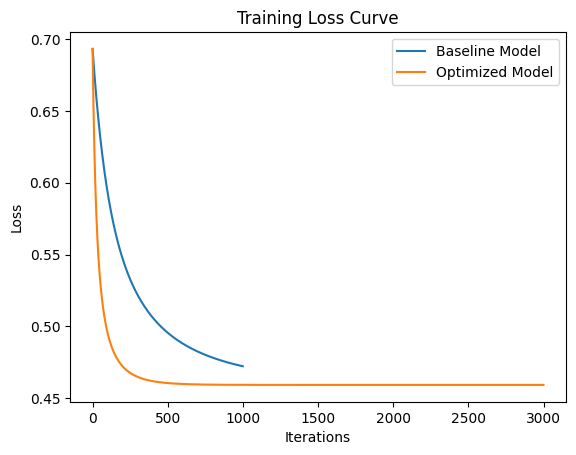

In [21]:
import matplotlib.pyplot as plt

plt.plot(losses_base, label="Baseline Model")
plt.plot(losses_opt, label="Optimized Model")

plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

In [22]:
print("Initial Loss (Baseline):", losses_base[0])
print("Final Loss (Baseline):", losses_base[-1])

print("Initial Loss (Optimized):", losses_opt[0])
print("Final Loss (Optimized):", losses_opt[-1])

Initial Loss (Baseline): 0.6931471785599453
Final Loss (Baseline): 0.4722456262821583
Initial Loss (Optimized): 0.6931471785599453
Final Loss (Optimized): 0.45924781851094293


## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [24]:
# Baseline predictions
y_pred_base, y_prob_base = predict(X_test, w_base, b_base)

# Optimized predictions
y_pred_opt, y_prob_opt = predict(X_test, w_opt, b_opt)

In [25]:
def accuracy(y, y_pred):
    return np.mean(y == y_pred)

def precision(y, y_pred):
    tp = np.sum((y==1)&(y_pred==1))
    fp = np.sum((y==0)&(y_pred==1))
    return tp/(tp+fp+1e-9)

def recall(y, y_pred):
    tp = np.sum((y==1)&(y_pred==1))
    fn = np.sum((y==1)&(y_pred==0))
    return tp/(tp+fn+1e-9)

def f1(y, y_pred):
    p = precision(y,y_pred)
    r = recall(y,y_pred)
    return 2*p*r/(p+r+1e-9)

In [26]:
def confusion_matrix(y, y_pred):
    tp = np.sum((y==1)&(y_pred==1))
    tn = np.sum((y==0)&(y_pred==0))
    fp = np.sum((y==0)&(y_pred==1))
    fn = np.sum((y==1)&(y_pred==0))
    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

In [27]:
def roc_auc(y, probs):
    idx = np.argsort(probs.flatten())
    y = y[idx]

    tpr = np.cumsum(y) / np.sum(y)
    fpr = np.cumsum(1 - y) / np.sum(1 - y)

    return np.trapz(tpr, fpr)

In [28]:
def pr_auc(y, probs):
    idx = np.argsort(-probs.flatten())
    y = y[idx]

    precision_curve = np.cumsum(y) / (np.arange(len(y)) + 1)
    recall_curve = np.cumsum(y) / np.sum(y)

    return np.trapz(precision_curve, recall_curve)

In [29]:
metrics_before = {
    "Accuracy": accuracy(y_test, y_pred_base),
    "Precision": precision(y_test, y_pred_base),
    "Recall": recall(y_test, y_pred_base),
    "F1": f1(y_test, y_pred_base),
    "ROC-AUC": roc_auc(y_test, y_prob_base),
    "PR-AUC": pr_auc(y_test, y_prob_base),
    "Runtime": runtime_base
}

metrics_after = {
    "Accuracy": accuracy(y_test, y_pred_opt),
    "Precision": precision(y_test, y_pred_opt),
    "Recall": recall(y_test, y_pred_opt),
    "F1": f1(y_test, y_pred_opt),
    "ROC-AUC": roc_auc(y_test, y_prob_opt),
    "PR-AUC": pr_auc(y_test, y_prob_opt),
    "Runtime": runtime_opt
}

/tmp/ipykernel_1854/1362387118.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(tpr, fpr)


In [30]:
comparison = pd.DataFrame(
    [metrics_before, metrics_after],
    index=["Baseline", "Optimized"]
)

comparison

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Runtime
Baseline,0.764706,0.693878,0.618182,0.653846,0.174212,0.687616,0.06349
Optimized,0.777778,0.723404,0.618182,0.666667,0.181818,0.689143,0.19918


In [31]:
print("Baseline Confusion Matrix:", confusion_matrix(y_test, y_pred_base))
print("Optimized Confusion Matrix:", confusion_matrix(y_test, y_pred_opt))

Baseline Confusion Matrix: {'TP': np.int64(34), 'TN': np.int64(83), 'FP': np.int64(15), 'FN': np.int64(21)}
Optimized Confusion Matrix: {'TP': np.int64(34), 'TN': np.int64(85), 'FP': np.int64(13), 'FN': np.int64(21)}


In [32]:
target_accuracy = 0.75
target_f1 = 0.70

print("Meets Accuracy Target:", metrics_after["Accuracy"] >= target_accuracy)
print("Meets F1 Target:", metrics_after["F1"] >= target_f1)

Meets Accuracy Target: True
Meets F1 Target: False


## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

## Ans1.
-Sigmoid activation function

-Binary cross-entropy loss function

-Forward propagation (linear model + activation)

-Gradient computation for weights and bias

-Gradient descent parameter updates

-Prediction using probability thresholding

-Evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC)



## Ans2.
-Loss decreased steadily over iterations, showing effective learning

-Optimized model converged faster due to higher learning rate

-Final loss was lower with more epochs, improving performance

-Feature scaling ensured stable updates and smooth convergence

-No major oscillations, indicating appropriate learning rate



## Ans3.
-Understood the mathematical working of Logistic Regression

-Learned how gradient descent drives model learning

-Saw the importance of feature scaling for stable convergence

-Observed impact of class imbalance on precision and recall

-Gained insight into how hyperparameters affect performance
